In [84]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

import run_fair

import utils_inverse
import jax
import jax.numpy as jnp

import utils_ML

import seaborn as sns
from cmcrameri import cm

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Evaluate performance of inverse model-optimized scenarios against FaIR

## 1. Generate baseline train and test datasets with FaIR

In [8]:
# Select agents
agents = ['CO2']

# Generate tier 1 and tier 2 scenarios
emis_dict_tier1, emis_dict_tier2 = run_fair.load_scenarioMIP_CMIP7(agents)
scenarios_tier1, scenarios_tier2 = list(emis_dict_tier1.keys()), list(emis_dict_tier2.keys())

# Generate DECK scenarios
emis_dict_DECK = run_fair.load_DECK_CMIP7(agents)
scenarios_DECK = list(emis_dict_DECK.keys())

# Generate CS3 Global Change Outlook scenarios
emis_dict_CS3 = run_fair.load_CS3(agents, emis_dict_tier1)
scenarios_CS3 = list(emis_dict_CS3.keys())

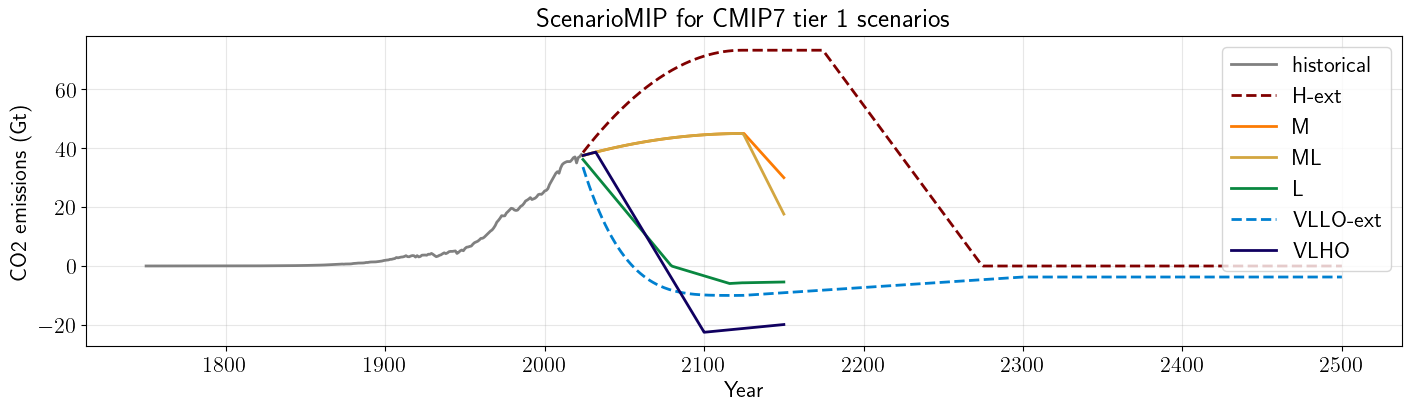

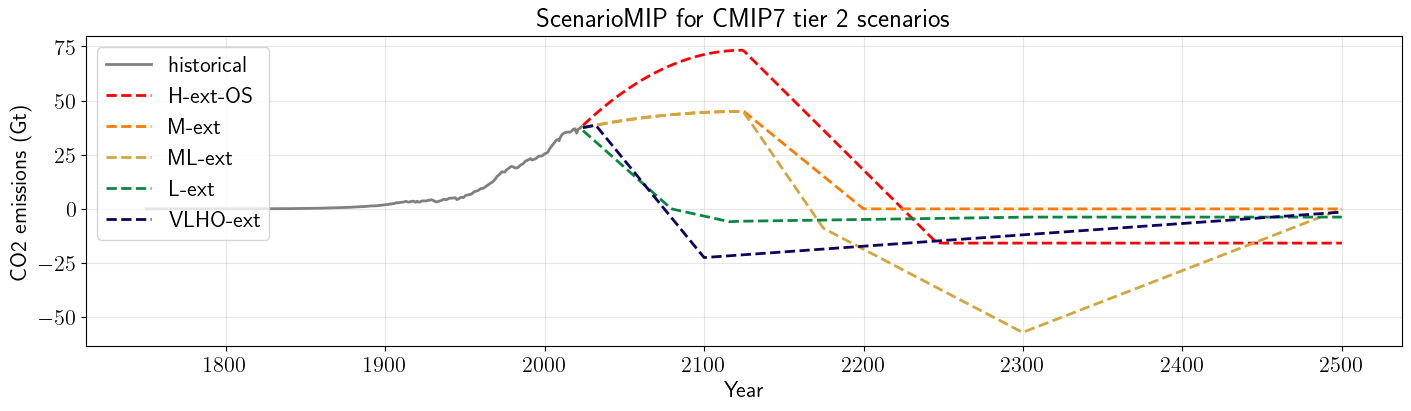

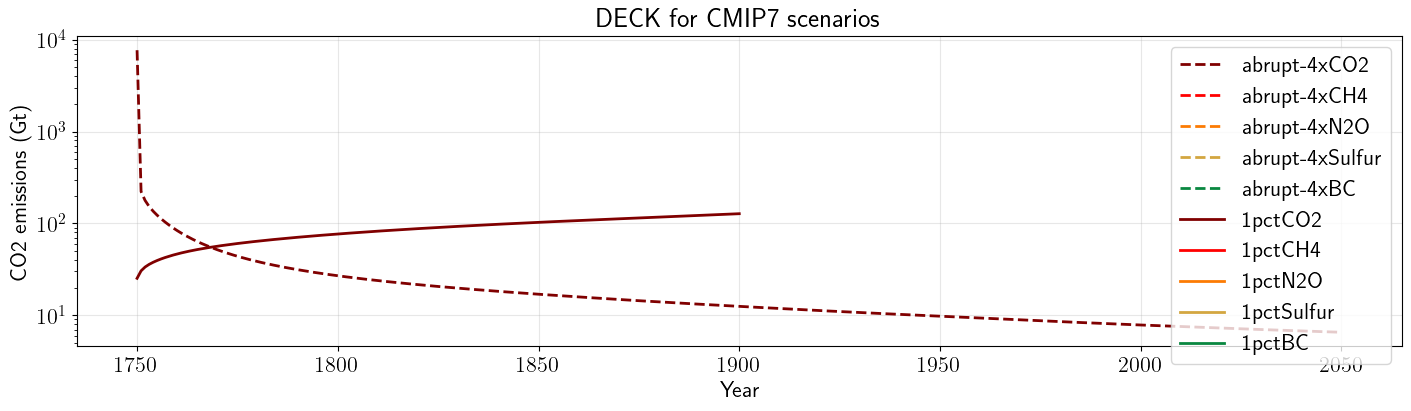

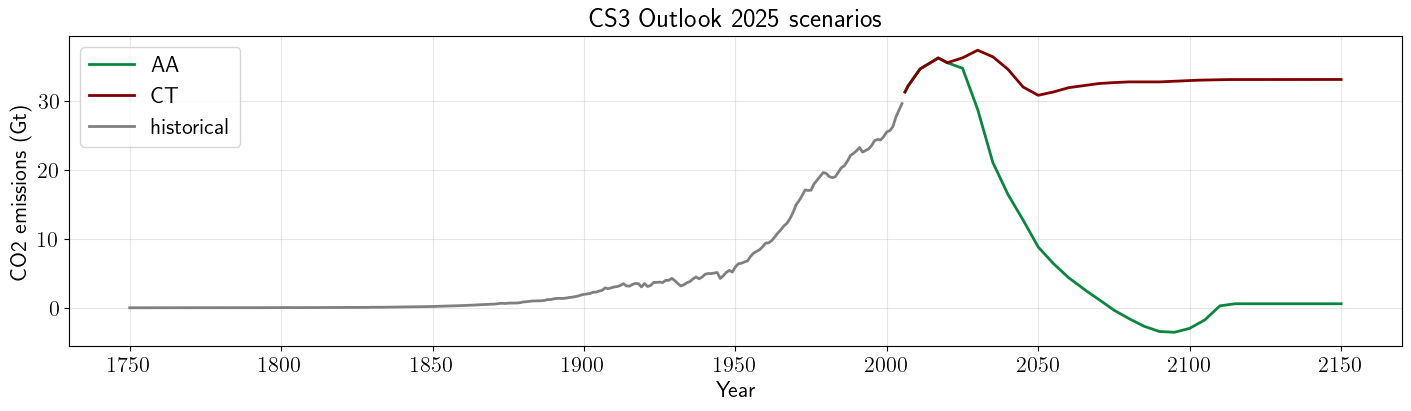

In [10]:
# Plot emissions scenarios (optional)
agent = 'CO2'
run_fair.plot_emissions(emis_dict_tier1, agent, 'ScenarioMIP for CMIP7 tier 1')
run_fair.plot_emissions(emis_dict_tier2, agent, 'ScenarioMIP for CMIP7 tier 2')
run_fair.plot_emissions(emis_dict_DECK, agent, 'DECK for CMIP7', MIP='DECK')
run_fair.plot_emissions(emis_dict_CS3, agent, 'CS3 Outlook 2025', MIP='CS3')

In [11]:
# Run FaIR for each scenario to get temperature change
delT_dict_tier1 = run_fair.get_delT(emis_dict_tier1, scenarios_tier1, agents, MIP='ScenarioMIP_tier1')
delT_dict_tier2 = run_fair.get_delT(emis_dict_tier2, scenarios_tier2, agents, MIP='ScenarioMIP_tier2')
delT_dict_DECK = run_fair.get_delT(emis_dict_DECK, scenarios_DECK, agents, MIP='DECK')
delT_dict_CS3 = run_fair.get_delT(emis_dict_CS3, scenarios_CS3, agents, MIP='CS3')

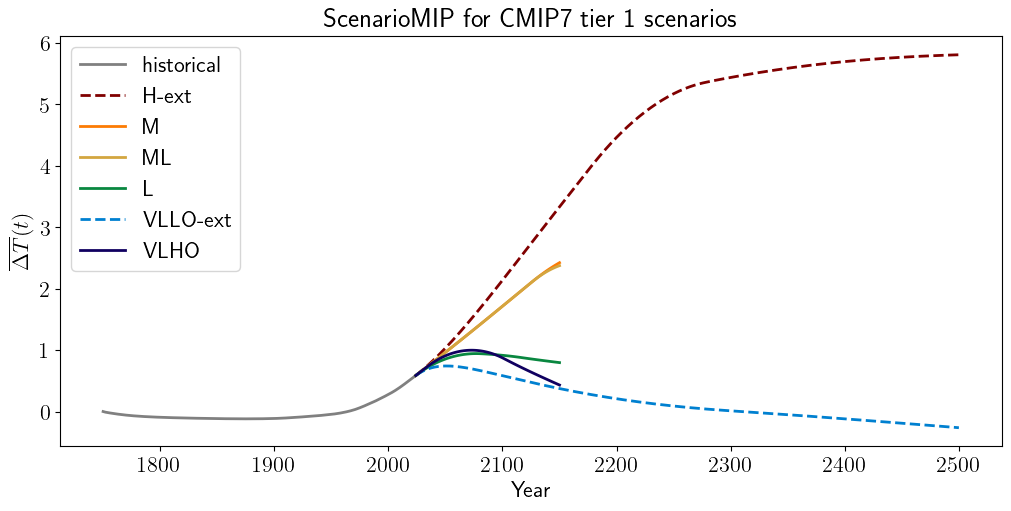

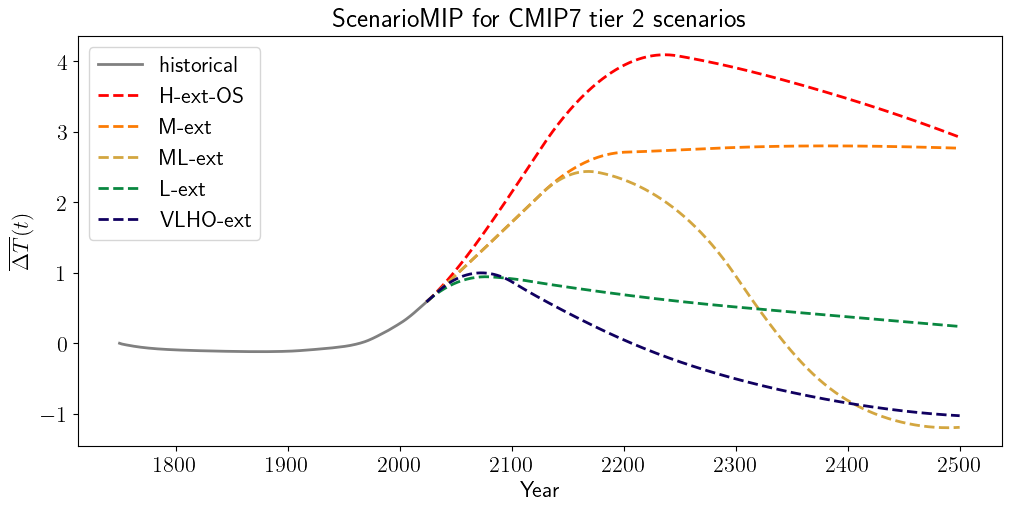

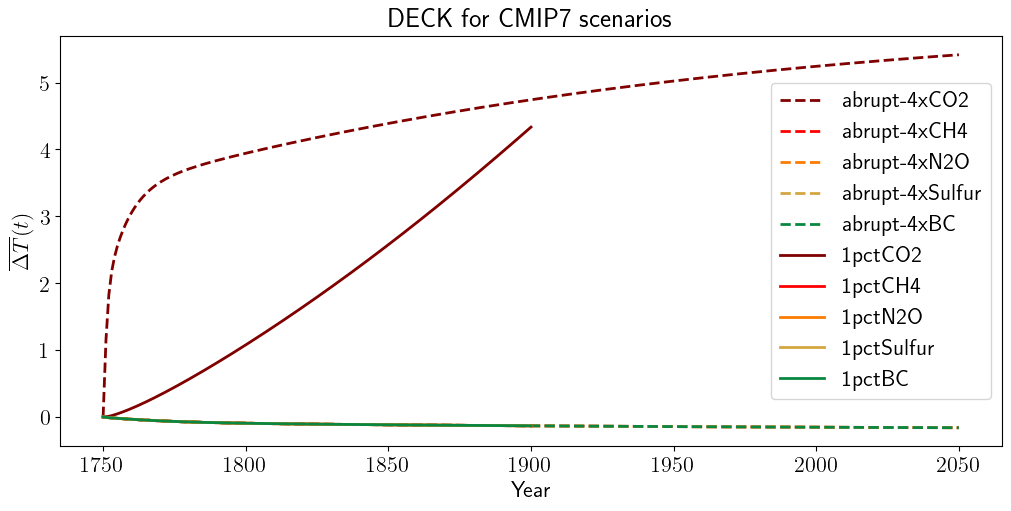

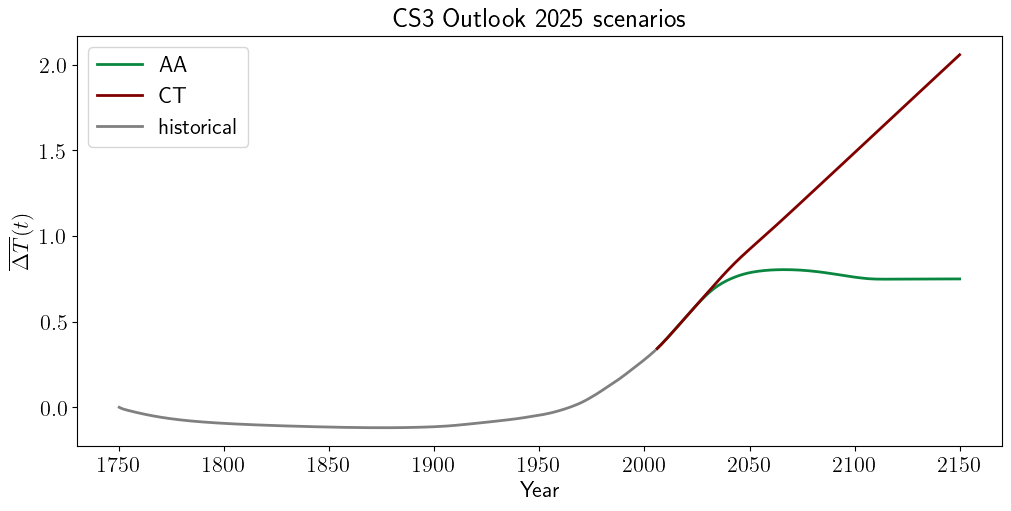

In [12]:
# Plot temperature change (optional)
run_fair.plot_delT(delT_dict_tier1, scenarios_tier1, 'ScenarioMIP for CMIP7 tier 1')
run_fair.plot_delT(delT_dict_tier2, scenarios_tier2, 'ScenarioMIP for CMIP7 tier 2')
run_fair.plot_delT(delT_dict_DECK, scenarios_DECK, 'DECK for CMIP7', MIP='DECK')
run_fair.plot_delT(delT_dict_CS3, scenarios_CS3, 'CS3 Outlook 2025', MIP='CS3')

In [100]:
# Create series datastructure for LSTM input
series_tier1 = []
for scen in scenarios_tier1:
  if scen != 'historical':
    needs_history = True
  else:
    needs_history = False
  series_tier1.append((emis_dict_tier1[scen], delT_dict_tier1[scen], needs_history))

series_tier2 = []
for scen in scenarios_tier2:
  if scen != 'historical':
    needs_history = True
  else:
    needs_history = False
  series_tier2.append((emis_dict_tier2[scen], delT_dict_tier2[scen], needs_history))

scenarios_DECK_lim, series_DECK_lim = [], []
for scen in scenarios_DECK:
  for a in agents:
    if a in scen:
      scenarios_DECK_lim.append(scen)
      series_DECK_lim.append((emis_dict_DECK[scen], delT_dict_DECK[scen], False))
      continue

series_CS3 = []
for scen in scenarios_CS3:
  if scen != 'historical':
    series_CS3.append((emis_dict_CS3[scen], delT_dict_CS3[scen], True))
  else:
    series_CS3.append((emis_dict_CS3[scen], delT_dict_CS3[scen], False))

## 2. Generate optimal training datasets from inverse model emissions time series

In [31]:
import utils_inverse
ICs = ['constant','ramp','gaussian']
targets = ['tier1', 'tier2', 'DECK', 'all']
emis_dict_opt = {}
for IC in ICs:
  for t in targets:
    path = f'checkpoints/co2/inverse_{IC}_{t}_co2_only.pkl'
    out = utils_inverse.load_inverse_ckpt(path)

    scen = f'opt_{IC}_{t}'
    emis_dict_opt[scen] = {}
    for a in agents:
      emis_dict_opt[scen][a] = out['U_traj'][-1][a]

scenarios_opt = list(emis_dict_opt.keys())
delT_dict_opt = run_fair.get_delT(emis_dict_opt, scenarios_opt, agents, MIP='Optimal')

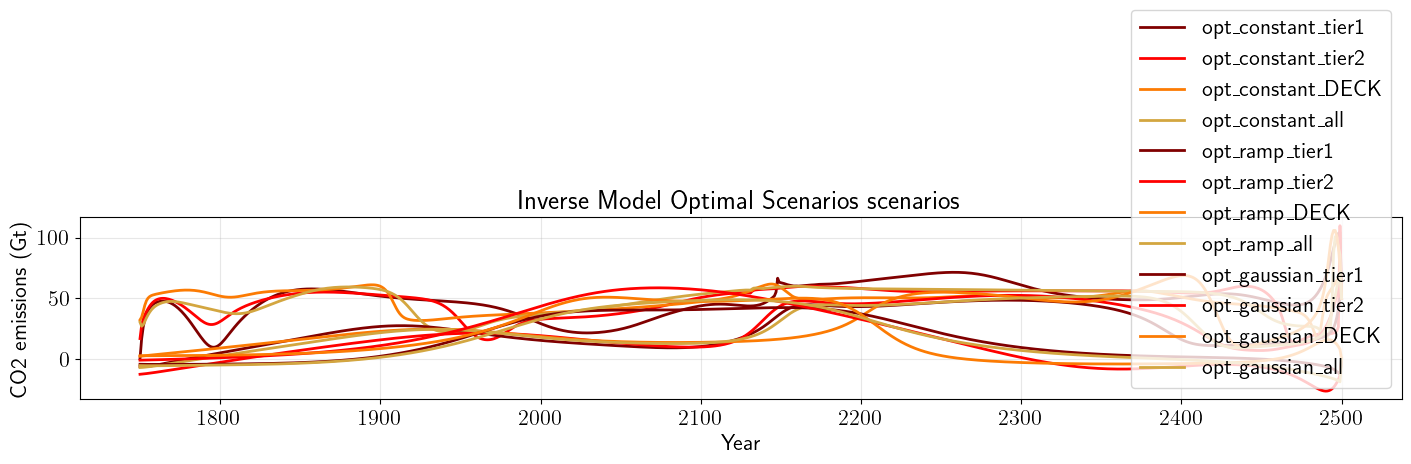

In [36]:
# Plot emissions scenarios (optional)
agent = 'CO2'
run_fair.plot_emissions(emis_dict_opt, agent, 'Inverse Model Optimal Scenarios', MIP='Optimal')

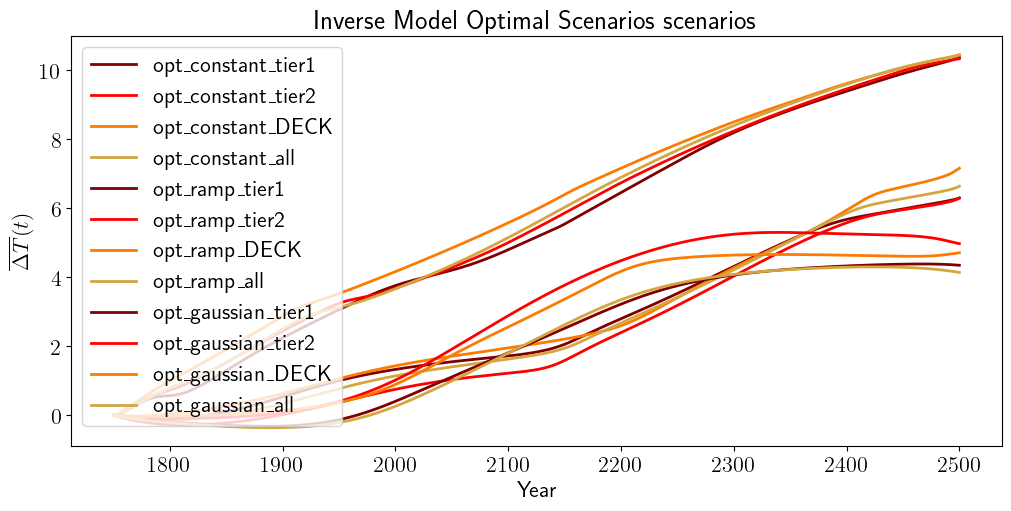

In [37]:
run_fair.plot_delT(delT_dict_opt, scenarios_opt, 'Inverse Model Optimal Scenarios', MIP='Optimal')

In [46]:
# Create series datastructure for LSTM input
series_opt = []
for scen in scenarios_opt:
  series_opt.append((emis_dict_opt[scen], delT_dict_opt[scen], False))

## 3. Evaluate LSTM performance
For all evaluations, the baseline emulator is trained on only tier 1 scenarios from ScenarioMIP for CMIP7: <i>Bracket</i> indicates an emulator trained only on the highest and lowest warming scenarios, while <i>Tier 1 All</i> indicated the baseline emulator is trained on all tier 1 scenarios. For the optimal emulator, <i>constant, ramp,</i> and <i>gaussian</i> indicate the initial condition the emissions time series was optimized starting from. The optimal performance was determined with respect to tier 1, tier 2, DECK, or all scenarios.

In [86]:
def prepare_jax_data(
    scenario_names,
    series_data,
    historical_emissions_dict=None,
    agents=['CO2']
):
    """
    Converts the notebook's series lists (emissions, temp, needs_history) into JAX feature matrices.
    Strictly respects the 'needs_history' flag for each scenario.
    """
    data_map = {}

    # Ensure lists are same length
    if len(scenario_names) != len(series_data):
        raise ValueError(f"Mismatch: {len(scenario_names)} names vs {len(series_data)} series items.")

    for name, (scen_emis, y_raw, needs_history) in zip(scenario_names, series_data):

        # 1. Determine History
        # Only pass historical emissions if this specific scenario needs it
        hist_to_use = historical_emissions_dict if needs_history else None

        # 2. Generate Features
        # utils_inverse.make_features_emissions_generic handles the stitching + EMAs
        X = utils_inverse.make_features_emissions_generic(
            scen_emis,
            emis_hist_dict=hist_to_use,
            agents=agents
        )

        # 3. Align Labels
        y = np.array(y_raw, dtype=np.float32).ravel()

        # Clip to matching length (features can be slightly shorter due to lags)
        min_len = min(X.shape[0], y.shape[0])
        X = X[:min_len]
        y = y[:min_len]

        data_map[name] = (X, y)

    return data_map

def evaluate_groups_jax(
    test_scenarios,
    features_map,
    training_groups,
    lstm_hidden=16,
    lr=1e-2,
    epochs=500,
    seed=0
):
    """
    Trains JAX LSTM with Standard Scaling.
    Returns:
      - error_dict: SCALED RMSE (matches inverse model loss scale)
      - yhat_dict:  UNSCALED predictions (real units for plotting)
    """
    error_dict = {}
    yhat_dict = {}
    key = jax.random.PRNGKey(seed)

    for group_name, scenario_names_in_group in training_groups.items():
        # --- 1. Prepare Training Data ---
        X_train_list, y_train_list = [], []
        for scen in scenario_names_in_group:
            if scen in features_map:
                X_train_list.append(features_map[scen][0])
                y_train_list.append(features_map[scen][1])

        if not X_train_list:
            continue

        Xtr = np.vstack(X_train_list)
        ytr = np.concatenate(y_train_list)

        # --- 2. Compute Scaling Statistics (StandardScaler) ---
        mean_X, std_X = np.mean(Xtr, axis=0), np.std(Xtr, axis=0) + 1e-6
        mean_y, std_y = np.mean(ytr), np.std(ytr) + 1e-6

        # Scale Training Data
        Xtr_scaled = (Xtr - mean_X) / std_X
        ytr_scaled = (ytr - mean_y) / std_y

        Xtr_jax = jnp.array(Xtr_scaled)
        ytr_jax = jnp.array(ytr_scaled)

        # --- 3. Train JAX Model ---
        in_dim = Xtr_jax.shape[-1]
        key, subkey = jax.random.split(key)

        # Initialize
        params = utils_inverse.init_lstm_params(subkey, in_dim=in_dim, hidden=lstm_hidden, out_dim=1)

        # Train (Using simple gradient descent or Adam from utils_inverse)
        # Assuming train_unrolled_lstm exists and handles the loop
        train_jit = jax.jit(utils_inverse.train_unrolled_lstm, static_argnames=("K",))
        params_final, _ = train_jit(params, Xtr_jax, ytr_jax, K=epochs, lr=lr, weight_decay=0.001)

        # --- 4. Evaluate (Scaled RMSE, Unscaled Output) ---
        error_dict[group_name] = {}
        yhat_dict[group_name] = {}

        for test_name in test_scenarios:
            if test_name in features_map:
                Xte, yte = features_map[test_name]

                # Scale Test Inputs
                Xte_scaled = (Xte - mean_X) / std_X
                Xte_jax = jnp.array(Xte_scaled)

                # Scale Test Targets (for RMSE calc)
                yte_scaled = (yte - mean_y) / std_y

                # Predict
                yhat_scaled_jax = utils_inverse.lstm_forward(params_final, Xte_jax)
                yhat_scaled = np.array(yhat_scaled_jax).ravel()

                # Metric: SCALED RMSE (matches JAX loss)
                rmse_scaled = np.sqrt(np.mean((yte_scaled - yhat_scaled)**2))
                error_dict[group_name][test_name] = rmse_scaled

                # Inverse Transform for Plotting (Real units)
                yhat_real = (yhat_scaled * std_y) + mean_y
                yhat_dict[group_name][test_name] = yhat_real

    return error_dict, yhat_dict

In [53]:
# Create training groups
training_groups = {'Bracket':['H-ext','VLLO-ext']}
training_groups['All_CMIP7'] = scenarios_tier1.copy()

for scen in scenarios_opt:
  training_groups[scen] = [scen]

scenarios_train, series_train = [], []
for i, scen in enumerate(scenarios_tier1):
  scenarios_train.append(scen)
  series_train.append(series_tier1[i])

for i, scen in enumerate(scenarios_opt):
  scenarios_train.append(scen)
  series_train.append(series_opt[i])

### 3a. Test on ScenarioMIP tier 1

In [102]:
# --- 1. Setup Historical Data Source ---
# Extract the raw historical emissions dictionary.
# Usually this is stored in emissions_dict_train['historical'] or similar.
# We pass this explicitly so it can be prepended only when needed.
historical_emissions_source = emis_dict_tier1['historical']

# --- 2. Prepare JAX Features ---
# We combine the lists of series tuples [(emis, y, needs_hist), ...]
all_scenarios = scenarios_train + scenarios_tier2 + scenarios_DECK_lim + scenarios_CS3
all_series = series_train + series_tier2 + series_DECK_lim + series_CS3

features_map_jax = prepare_jax_data(
    all_scenarios,
    all_series,
    historical_emissions_dict=historical_emissions_source,
    agents=agents
)

error_dict_tier1, yhat_dict_tier1 = evaluate_groups_jax(
    test_scenarios=scenarios_tier1,
    features_map=features_map_jax,
    training_groups=training_groups,
    lstm_hidden=16,
    lr=5e-2,
    epochs=400,
    seed=42
)

In [66]:
error_dict_tier1, yhat_dict_tier1 = evaluate_groups_jax(
    test_scenarios=scenarios_tier1,
    features_map=features_map_jax,
    training_groups=training_groups,
    lstm_hidden=16,
    lr=5e-2,
    epochs=400,
    seed=42
)

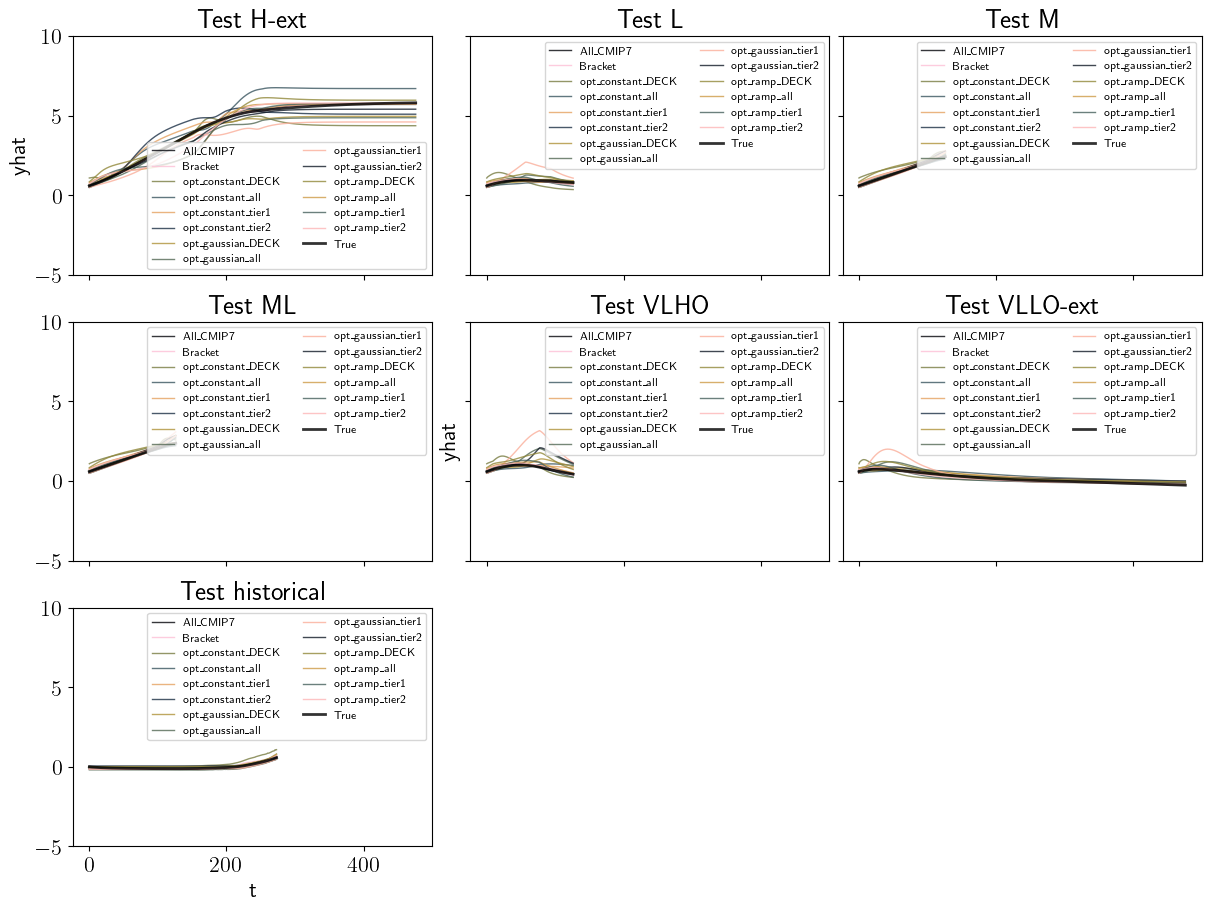

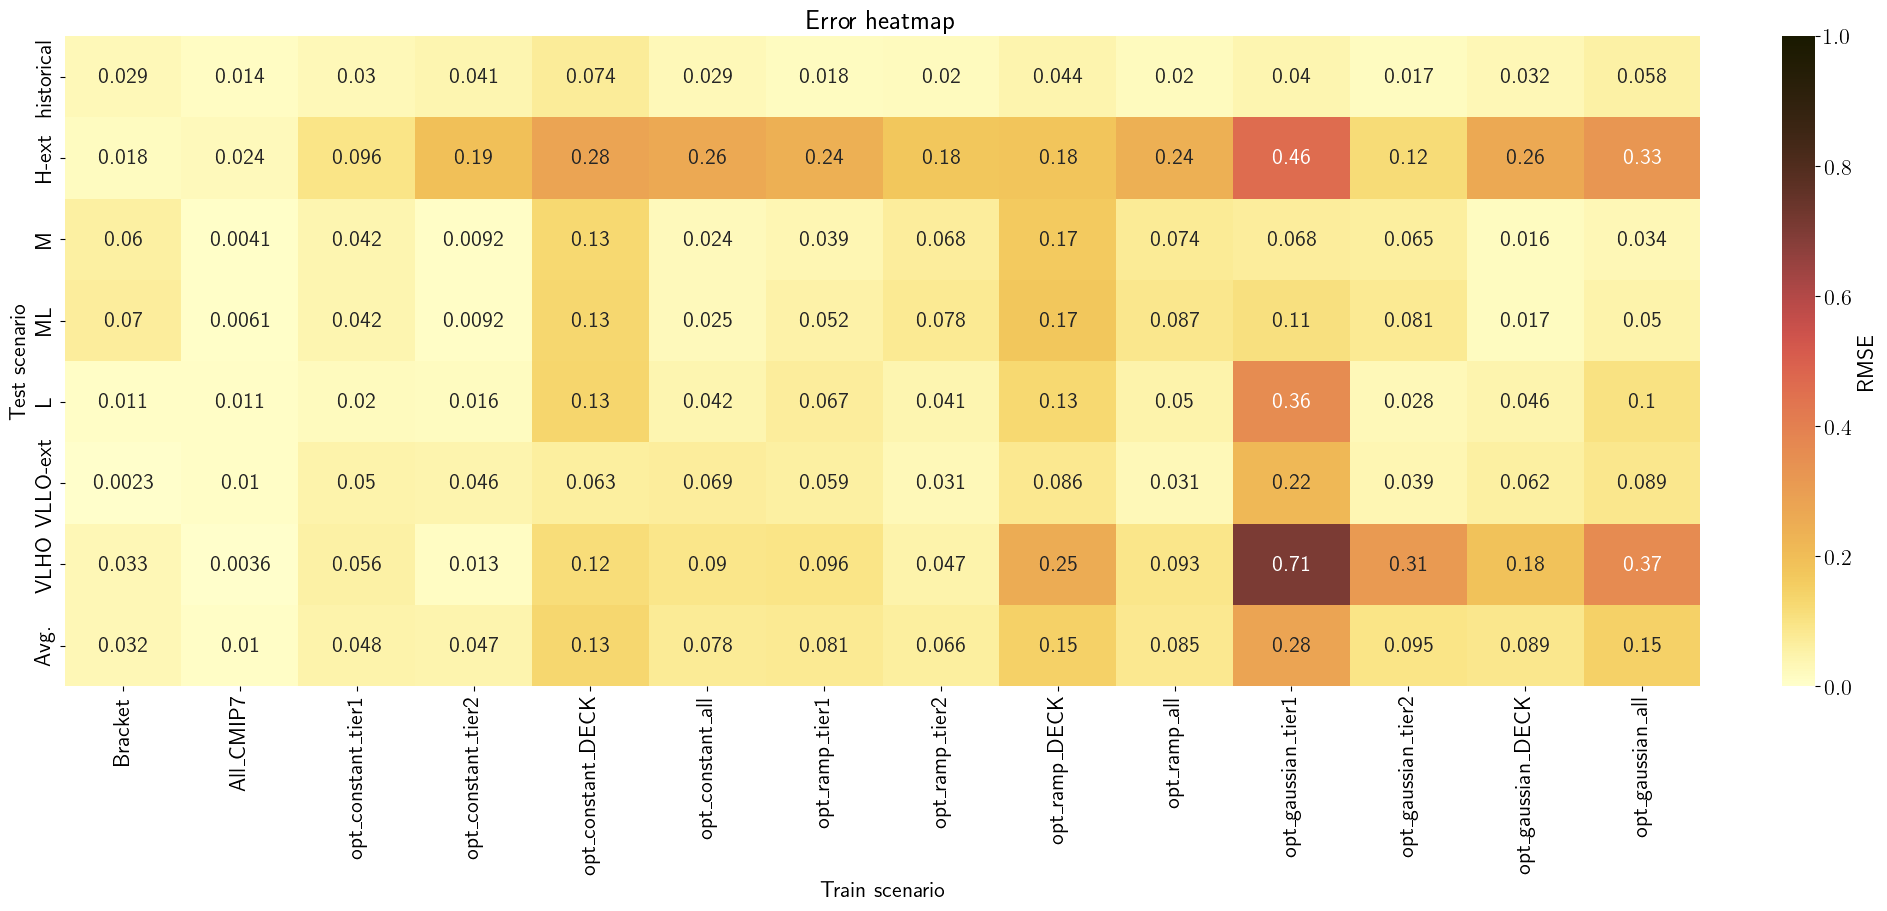

In [90]:
# Plot LSTM results
utils_ML.plot_yhats_grid(error_dict_tier1, yhat_dict_tier1, delT_dict_tier1)
utils_ML.plot_error_heatmap(error_dict_tier1, list(training_groups.keys()), scenarios_tier1)

### 3b. Test on ScenarioMIP tier 2

In [103]:
error_dict_tier2, yhat_dict_tier2 = evaluate_groups_jax(
    test_scenarios=scenarios_tier2,
    features_map=features_map_jax,
    training_groups=training_groups,
    lstm_hidden=16,
    lr=5e-2,
    epochs=400,
    seed=42
)

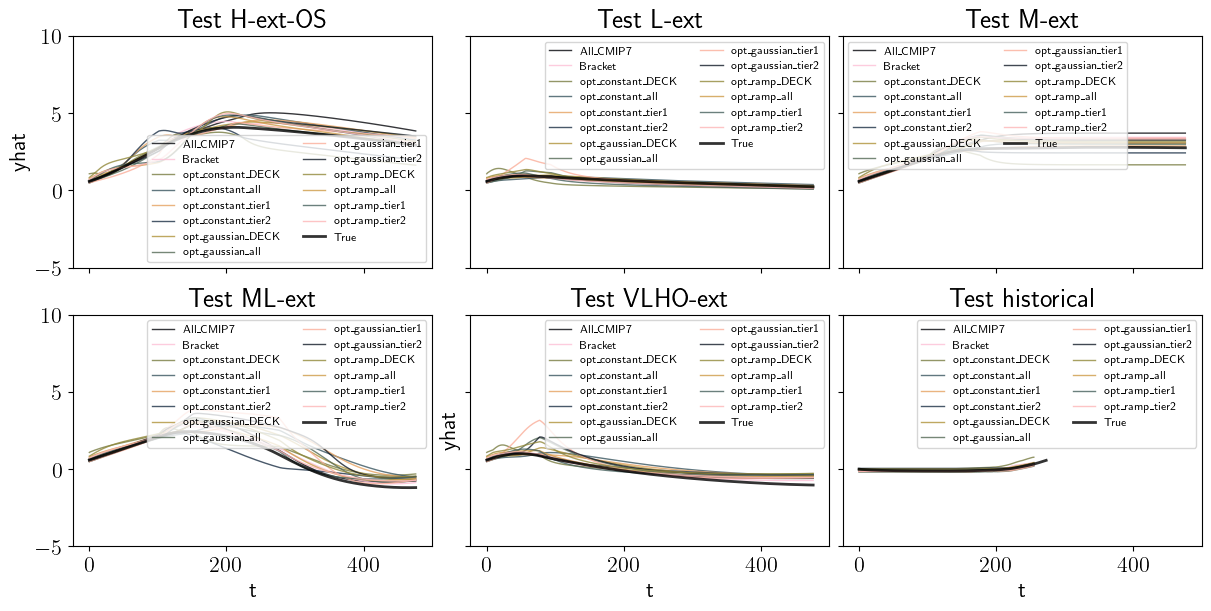

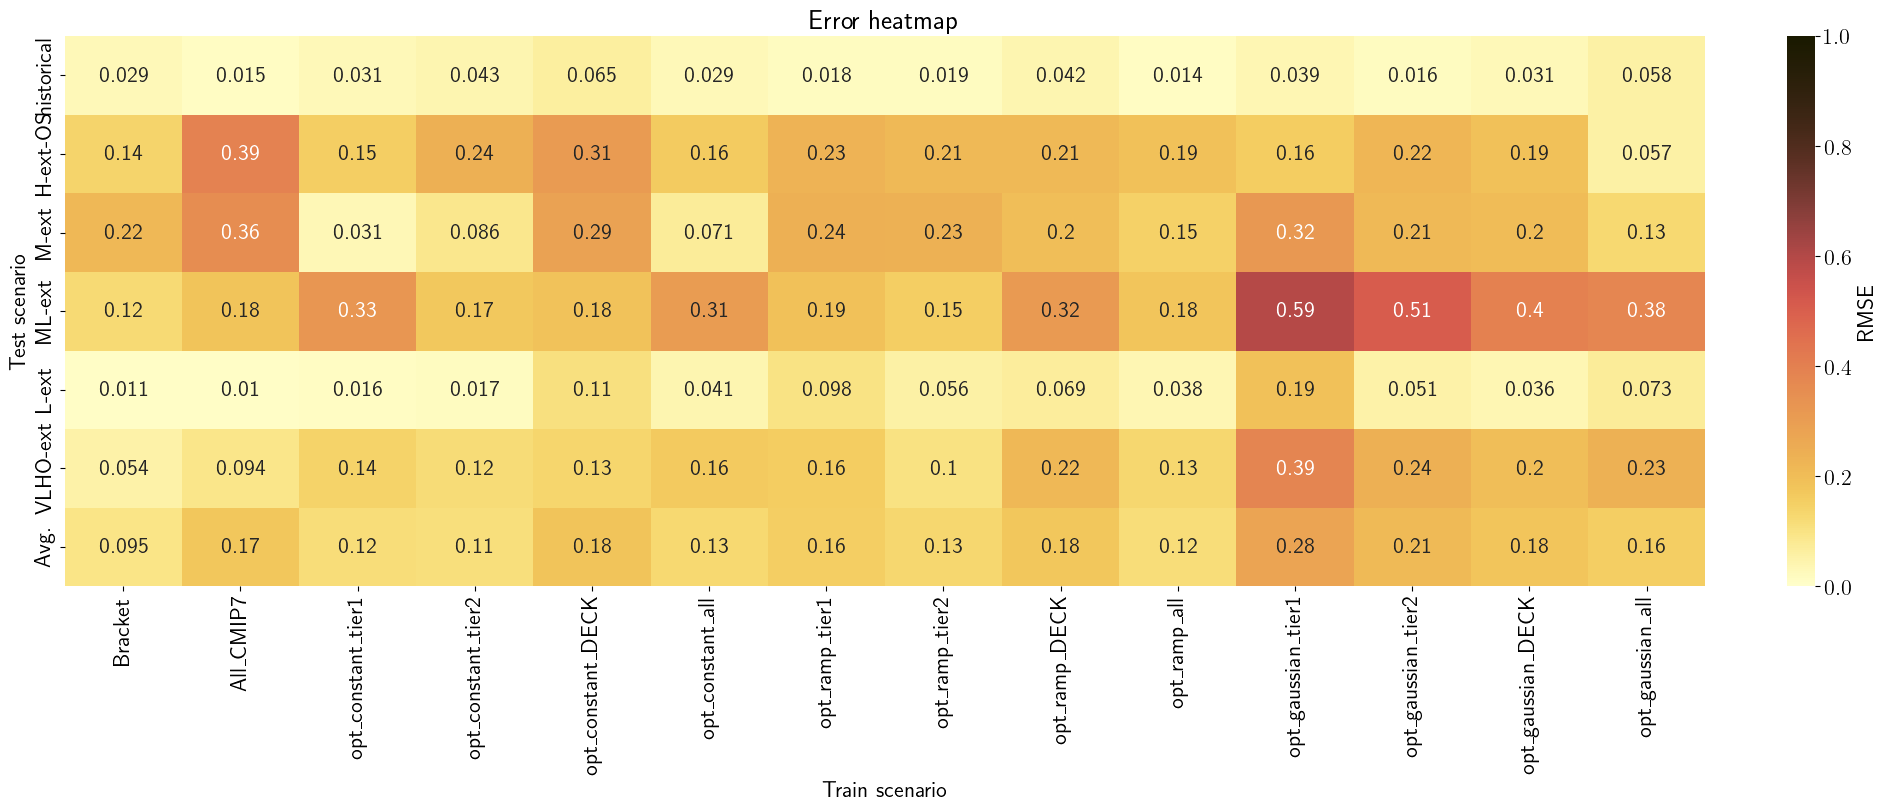

In [104]:
# Plot LSTM results
utils_ML.plot_yhats_grid(error_dict_tier2, yhat_dict_tier2, delT_dict_tier2)
utils_ML.plot_error_heatmap(error_dict_tier2, list(training_groups.keys()), scenarios_tier2)

### 3c. Test on DECK

In [105]:
error_dict_DECK, yhat_dict_DECK = evaluate_groups_jax(
    test_scenarios=scenarios_DECK_lim,
    features_map=features_map_jax,
    training_groups=training_groups,
    lstm_hidden=16,
    lr=5e-2,
    epochs=400,
    seed=42
)

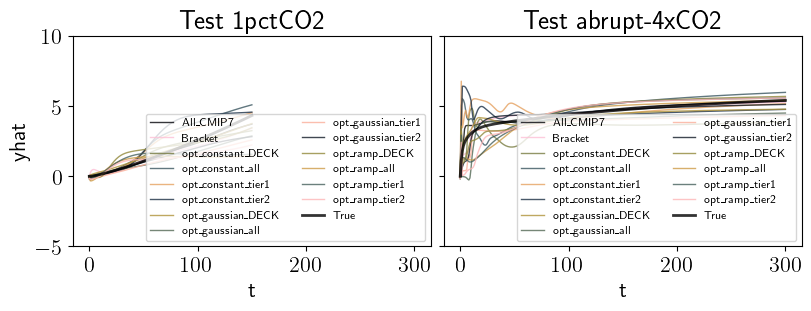

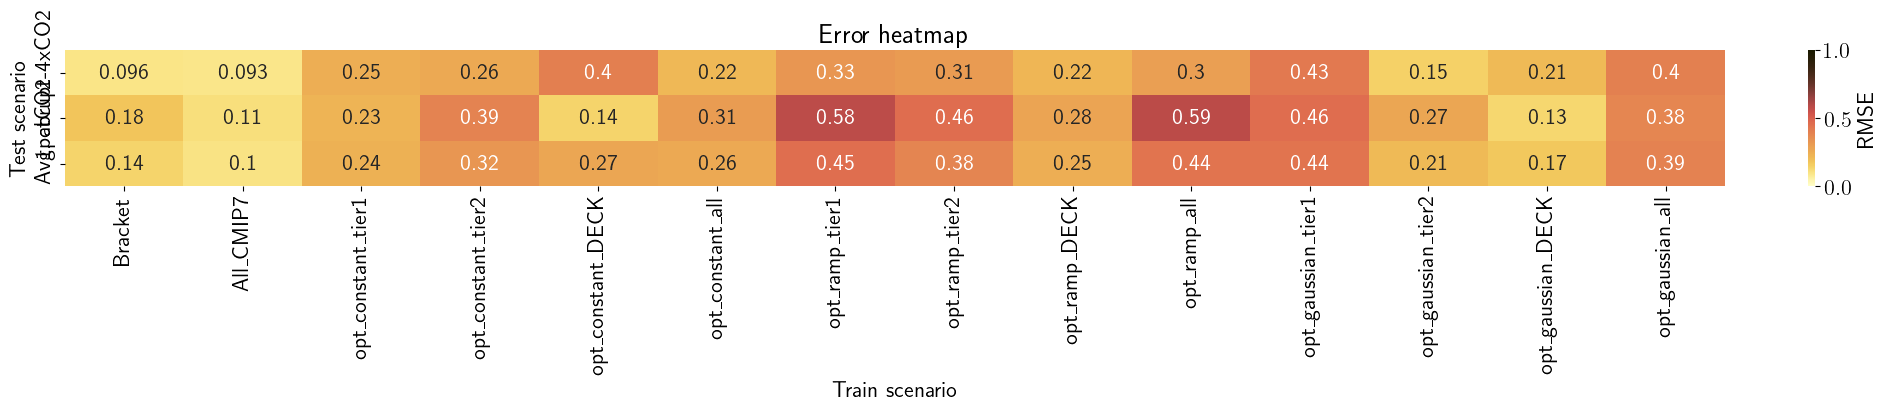

In [112]:
# Plot LSTM results
utils_ML.plot_yhats_grid(error_dict_DECK, yhat_dict_DECK, delT_dict_DECK)
utils_ML.plot_error_heatmap(error_dict_DECK, list(training_groups.keys()), scenarios_DECK_lim)

### 3d. Test on CS3

In [113]:
error_dict_CS3, yhat_dict_CS3 = evaluate_groups_jax(
    test_scenarios=scenarios_CS3,
    features_map=features_map_jax,
    training_groups=training_groups,
    lstm_hidden=16,
    lr=5e-2,
    epochs=400,
    seed=42
)

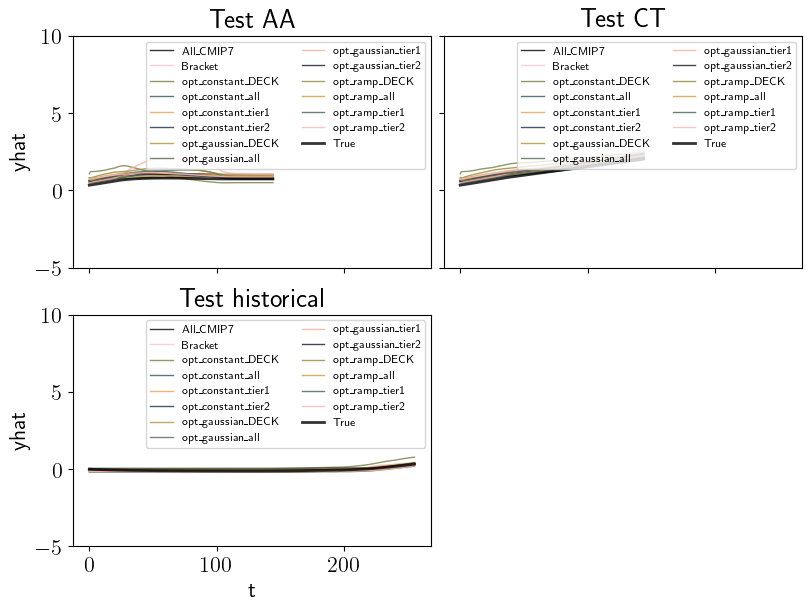

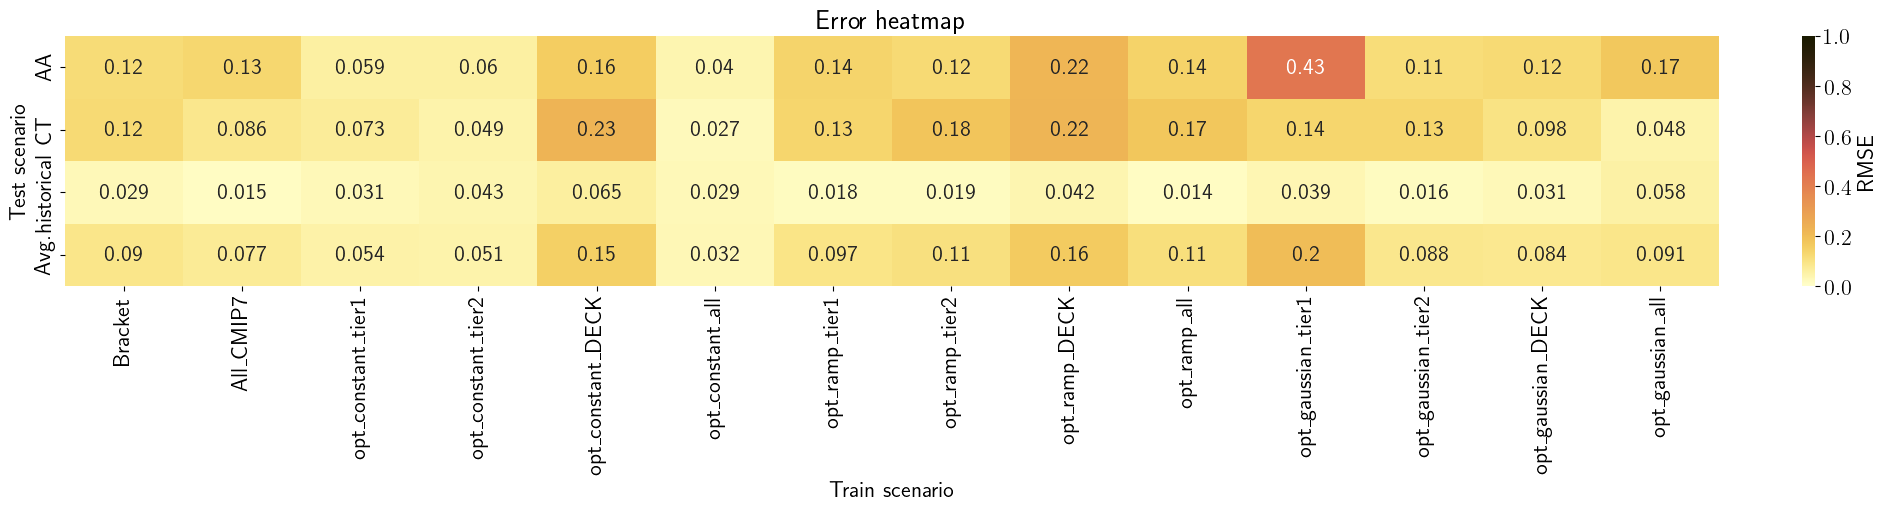

In [114]:
# Plot LSTM results
utils_ML.plot_yhats_grid(error_dict_CS3, yhat_dict_CS3, delT_dict_CS3)
utils_ML.plot_error_heatmap(error_dict_CS3, list(training_groups.keys()), scenarios_CS3)